In [1]:
# @title
# This should install all the necessary packages if you are working on colab
!pip install ducc0 astropy matplotlib scipy xarray zarr


%matplotlib inline
import numpy as np
import xarray as xr
from ducc0.wgridder import vis2dirty, dirty2vis
from scipy.constants import c as lightspeed
import matplotlib.pyplot as plt
import torch
from scipy.signal import fftconvolve
import matplotlib.colors as mcolors

# The data

The folder called ESO137.zarr here

https://drive.google.com/drive/folders/1H3ZIEa3fWmUchvfEW1Y5_su4bWEBFJ1c?usp=sharing

contains calibrated averaged data for a subset of the ESO137 field. Download it and upload it to colab.

Once downloaded, you can load it and inspect it with xarray as follows:

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
xds = xr.open_zarr('/content/drive/MyDrive/quiz/ESO137.zarr', chunks=None)
print(xds)
vis = xds.VIS.values
wgt = xds.WEIGHT.values
uvw = xds.UVW.values
mask = xds.MASK.values
freq = xds.FREQ.values
print(vis.shape, wgt.shape, uvw.shape, mask.shape, freq.shape)

<xarray.Dataset> Size: 3GB
Dimensions:  (chan: 72, row: 1731344, three: 3)
Coordinates:
  * chan     (chan) float64 576B 1.441e+09 1.441e+09 ... 1.499e+09 1.5e+09
Dimensions without coordinates: row, three
Data variables:
    FREQ     (chan) float64 576B ...
    MASK     (row, chan) uint8 125MB ...
    UVW      (row, three) float64 42MB ...
    VIS      (row, chan) complex128 2GB ...
    WEIGHT   (row, chan) float64 997MB ...
Attributes: (12/20)
    bandid:      0
    beam_model:  None
    chan_high:   771
    chan_low:    699
    ddid:        0
    dec:         -1.0630073253375796
    ...          ...
    time_max:    5064154783.96309
    time_min:    5064151193.482062
    time_out:    5064152988.722561
    timeid:      0
    utc:         2019-05-09 21:09:48
    uv_max:      7170.355494360907
(1731344, 72) (1731344, 72) (1731344, 3) (1731344, 72) (72,)


# Question 1

Find the maximum absolute $u$ and $v$ coordinates using the `UVW` data variable. Also find the maximum frequency using the `FREQ` variable. Plot the $uv$-coverage by doing a scatter plot of $u$ against $v$.

The maximum absolute of u is |u| = 7294.89
The maximum absolute  of  v is |v| = 7695.03
Shapes of u and v are the same, correct.
The maximum frequency = 1.50e+09 Hz


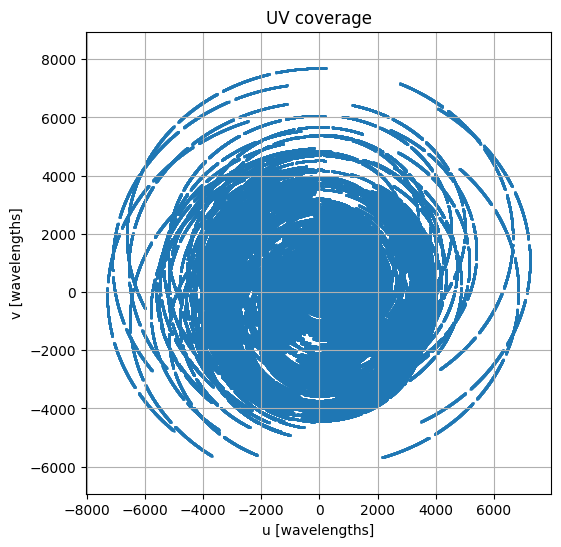

In [4]:
u = uvw[:, 0]  # let's extract u
v = uvw[:, 1] #  let's extract v
u_max = np.max(np.abs(u))
v_max = np.max(np.abs(v))
print(f"The maximum absolute of u is |u| = {u_max:.2f}")
print(f"The maximum absolute  of  v is |v| = {v_max:.2f}")
# let's first verify the shape of u and v
if u.shape == v.shape == (uvw.shape[0],):
    print("Shapes of u and v are the same, correct.")
else:
    print(f"Shape mismatch: u.shape = {u.shape}, v.shape = {v.shape}, uvw.shape = {uvw.shape}")

# Now let's find the maximum frequency
freq_max = np.max(freq)
print(f"The maximum frequency = {freq_max:.2e} Hz")

# Plot UV coverage
plt.figure(figsize=(6,6))
plt.scatter(u, v, s=1, alpha=0.5)
plt.xlabel('u [wavelengths]')
plt.ylabel('v [wavelengths]')
plt.title('UV coverage')
plt.axis('equal')
plt.grid(True)
plt.show()

# Question 2

Use the $uv$-coordinates and frequencies loaded above to compute the cell size that over-samples Nyquist by a factor of two. Report the cell size both radians and degrees.

In [5]:
print(f"The shape of uvw is {uvw.shape}")

The shape of uvw is (1731344, 3)


It is very inportant to ensure the size of uvw.  
So the number of number of visibility  is: **1731344**

We know:

$ \Delta x = \frac{1}{2 u_{\rm max}} $

It depends on:

* $u_{\rm max}$ – the maximum baseline in the UV plane
* Frequency – since UV coordinates scale with wavelength

And for oversampling Nyquist we multiplying by $1/2$.


In [6]:
# Maximum spatial frequency in each direction
uv_max = np.max(np.abs(uvw[:, :2]))  # max over u and v
print(f"The Maximum UV = {uv_max:.2f} wavelengths")

#  Maximum frequency
freq_max = np.max(freq)
print(f"Maximum frequency = {freq_max:.2e} Hz")

# Nyquist cell size
cell_rad = 1.0 / (2 * uv_max * freq_max / lightspeed)  # for the Nyquist
cell_rad /= 2  # oversample by factor of 2
cell_deg = np.rad2deg(cell_rad)

print(f"Cell size: {cell_rad:.3e} radians, {cell_deg:.3e} degrees")

The Maximum UV = 7695.03 wavelengths
Maximum frequency = 1.50e+09 Hz
Cell size: 6.493e-06 radians, 3.720e-04 degrees


# Question 3

Choose a field of view of 0.5 degrees and make a dirty image, denoted $I^D$, using the `vis2dirty` function from `ducc` (you can inspect the function signature using `help(vis2dirty)`). Make sure to use an even number of pixels and set the gridding accuracy (i.e. the `epsilon` parameter) to $10^{-6}$. Remember to pass in the `MASK` as this tells the function which data points to ignore (e.g. these may be corrupted by RFI).

In [7]:
help(vis2dirty)

Help on built-in function vis2dirty in module ducc0.wgridder:

vis2dirty(...) method of pybind11_builtins.pybind11_detail_function_record_v1_system_libstdcpp_gxx_abi_1xxx_use_cxx11_abi_1 instance
    vis2dirty(*, uvw: numpy.ndarray, freq: numpy.ndarray, vis: numpy.ndarray, wgt: numpy.ndarray | None = None, npix_x: typing.SupportsInt = 0, npix_y: typing.SupportsInt = 0, pixsize_x: typing.SupportsFloat, pixsize_y: typing.SupportsFloat, epsilon: typing.SupportsFloat, do_wgridding: bool = False, nthreads: typing.SupportsInt = 1, verbosity: typing.SupportsInt = 0, mask: numpy.ndarray | None = None, flip_u: bool = False, flip_v: bool = False, flip_w: bool = False, divide_by_n: bool = True, dirty: numpy.ndarray | None = None, sigma_min: typing.SupportsFloat = 1.1, sigma_max: typing.SupportsFloat = 2.6, center_x: typing.SupportsFloat = 0.0, center_y: typing.SupportsFloat = 0.0, allow_nshift: bool = True, double_precision_accumulation: bool = False) -> numpy.ndarray


    Converts visibilities 

In [8]:
fov_deg = 0.5  # degrees

# Now let's compute image size (npix) based on cell size
npix = int(fov_deg / cell_deg)
# we need to ensure even number
if npix % 2:
    npix += 1
print(f"Image size: {npix} x {npix} pixels")

# Let's make dirty image using vis2dirty
dirty_image = vis2dirty(
    uvw=uvw,
    freq=freq,
    vis=vis,
    wgt=wgt,
    mask=mask,
    npix_x=npix,
    npix_y=npix,
    pixsize_x=cell_rad,
    pixsize_y=cell_rad,
    epsilon=1e-6,
    do_wgridding=False,
    divide_by_n=False
)


Image size: 1344 x 1344 pixels


# Question 4

In order to make the psf, you need to convert the `WEIGHT` parameter into the same dtype as `VIS` and pass this to the function instead of the visibilities. In this case, you should not provide anything for the `wgt` parameter. Make the PSF twice the size of the dirty image by doubling the number of pixels.

In [9]:
# PSF image size (2x dirty image)
npix_psf = 2 * npix
print(f"PSF image size: {npix_psf} x {npix_psf} pixels")

# Convert weights to same dtype as vis
weight_vis = wgt.astype(vis.dtype)

# Compute PSF
# we need to pass weights instead of visibilities
psf_full = vis2dirty(
    uvw=uvw,
    freq=freq,
    vis=weight_vis,
    npix_x=npix_psf,
    npix_y=npix_psf,
    pixsize_x=cell_rad,
    pixsize_y=cell_rad,
    epsilon=1e-6,
    do_wgridding=False,
    divide_by_n=False
)


PSF image size: 2688 x 2688 pixels


# Question 5

Normalise the dirty image and PSF by the sum of the weights(i.e. the peak of the PSF) to get them in units of Jy/beam and plot them both using `plt.imshow`.

In [10]:
#help(plt.imshow)

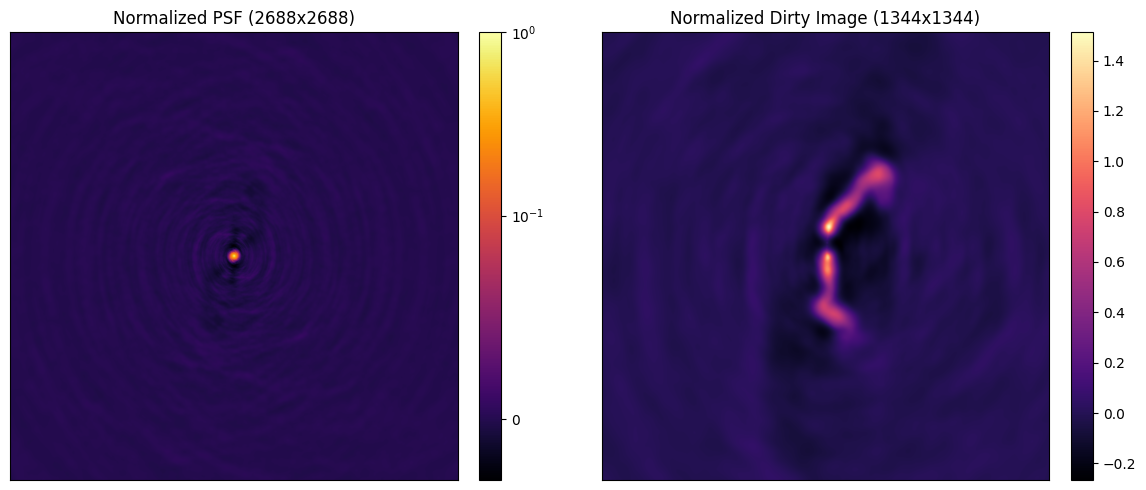

In [11]:
# Normalize by PSF peak so units are Jy/beam
wsum = psf_full.max()
psf_full /= wsum
dirty_image /= wsum

# Plot PSF, and Dirty Image together
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PSF
im1 = axes[0].imshow(psf_full,
                     norm=mcolors.SymLogNorm(linthresh=1e-1, vmin=psf_full.min(), vmax=psf_full.max()),
                     origin='lower', cmap='inferno')
axes[0].set_title(f"Normalized PSF ({npix_psf}x{npix_psf})")
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Dirty Image
im2 = axes[1].imshow(dirty_image, origin='lower', cmap='magma')
axes[1].set_title(f"Normalized Dirty Image ({npix}x{npix})")
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

# Remove ticks
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

# Question 6

Write down a basic implementation of the Hogbom CLEAN algorithm (you can use all resources you want). Use a loop gain $\gamma=0.1$ and only clean down to $0.1$ of the peak in the image (i.e. you can terminate the algorithm when the peak of the residual is $0.1 I^D$). Plot the resulting model and residual images. You might need to saturate the model plot (e.g. by setting vmax=$10^{-6}$ or using a log-scaling) to see the model components.

**From** : https://www.physik.uni-bielefeld.de/~zwu/other_page/clean-note.pdf

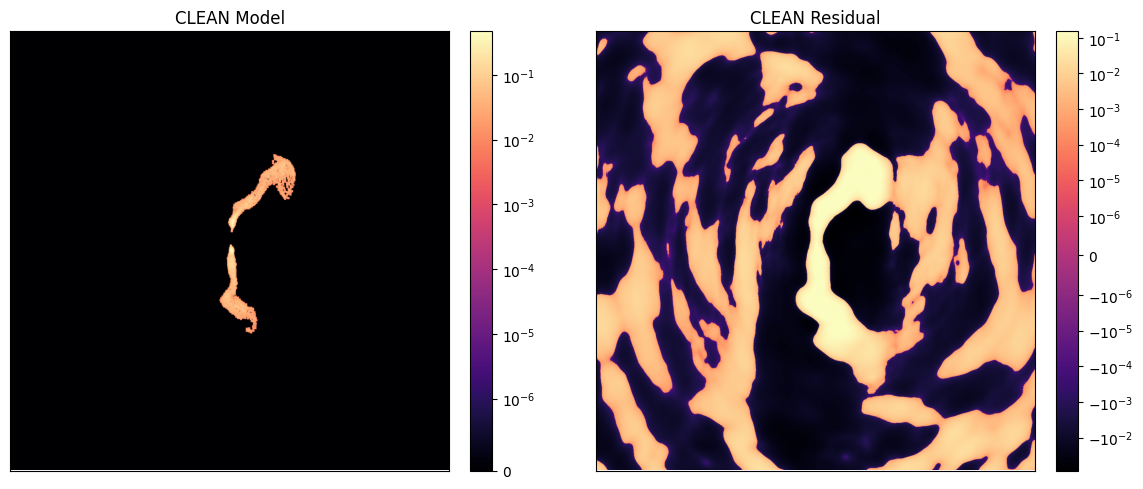

CLEAN finished after 966 iterations


In [12]:
from scipy.ndimage import shift
from scipy.signal import convolve2d
from scipy.signal.windows import gaussian

gamma = 0.1                # loop gain
threshold = 0.1 * dirty_image.max()  # stop at 0.1 of peak
max_iter = 10000

#  Initialize
residual = dirty_image.copy()
model = np.zeros_like(dirty_image)

# Crop psf_full to match dirty_image size before normalization
# npix_psf is 2*npix, so to get a central npix x npix array, we start at npix_psf//4 and end at npix_psf//4 + npix
psf_clean_sized = psf_full[npix_psf//4 : npix_psf//4 + npix,
                           npix_psf//4 : npix_psf//4 + npix]

psf_norm = psf_clean_sized / psf_clean_sized.max() # normalize PSF to 1 at peak
psf_center = np.array(psf_norm.shape) // 2  # center of PSF, now relative to the cropped PSF

# --- CLEAN loop ---
iter_count = 0
while residual.max() > threshold and iter_count < max_iter:
    iter_count += 1
    # Find peak in residual
    peak_val = residual.max()
    peak_pos = np.unravel_index(np.argmax(residual), residual.shape)

    # Record point source in model
    model[peak_pos] += gamma * peak_val

    # Subtract scaled PSF from residual
    dy = peak_pos[0] - psf_center[0]
    dx = peak_pos[1] - psf_center[1]
    psf_shifted = shift(psf_norm, shift=(dy, dx), order=0, mode='constant', cval=0)
    residual -= gamma * peak_val * psf_shifted

# restore with CLEAN beam
# Here we assume the PSF main lobe is roughly Gaussian
# You could fit it, but for simplicity let's use a small Gaussian
beam_size = 3  # pixels
gauss_beam = gaussian(2*beam_size+1, std=beam_size)
clean_beam = np.outer(gauss_beam, gauss_beam)
clean_model = convolve2d(model, clean_beam, mode='same')
restored_image = clean_model + residual

#  Plot results in professor-style
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# CLEAN Model
im0 = axes[0].imshow(clean_model,
                     norm=mcolors.SymLogNorm(linthresh=1e-6, vmin=clean_model.min(), vmax=clean_model.max()),
                     origin='lower', cmap='magma')
axes[0].set_title("CLEAN Model")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# CLEAN Residual
im1 = axes[1].imshow(residual,
                     norm=mcolors.SymLogNorm(linthresh=1e-6, vmin=residual.min(), vmax=residual.max()),
                     origin='lower', cmap='magma')
axes[1].set_title("CLEAN Residual")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()
print(f"CLEAN finished after {iter_count} iterations")

# Question 7

Find the Tikhonov regularized solution

$$ x = \left(H + \lambda I\right)^{-1} I^D  $$

where $H$ is an operator that implements a convolution with the PSF, $\lambda$ is the regulariser strength and $I$ is the identity. Use a value of $\lambda = 0.1$ for the strength of the regulariser. Hint - you will need to create a operator that implements the action of $(H + \lambda I)$ on an image the same size as $I^D$ and use the conjugate gradient algorithm to invert the operator. Plot the resulting model and dirty images.

Tikhonov result range: [-0.0071, 0.0149]


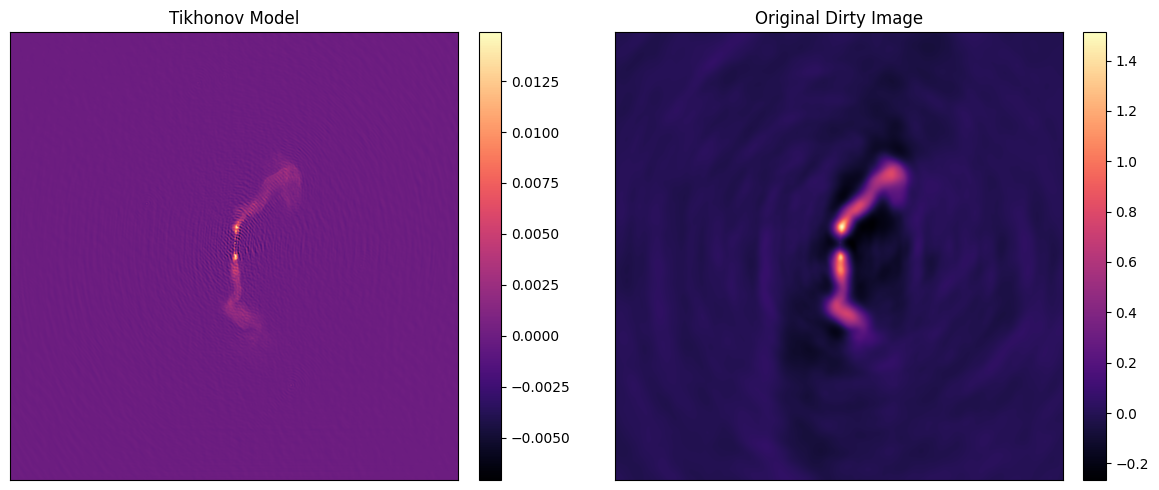

In [13]:
lam_tik = 0.1

# Convert dirty image to torch tensor
dirty_torch = torch.tensor(dirty_image, dtype=torch.float32)

# Define operator (H + lambda*I)
def hessian_plus_reg(x):
    """Applies (H + lambda*I) to x."""
    x_np = x.numpy()
    Hx = fftconvolve(x_np, psf_full, mode='same')  # convolution with PSF
    return torch.tensor(Hx + lam_tik * x_np, dtype=torch.float32)

# --- Conjugate Gradient Solver ---
def conjugate_gradient(A, b, max_iter=200, tol=1e-6):
    x = torch.zeros_like(b)
    r = b - A(x)
    p = r.clone()
    rsold = torch.sum(r * r)

    for i in range(max_iter):
        Ap = A(p)
        alpha = rsold / torch.sum(p * Ap)
        x = x + alpha * p
        r = r - alpha * Ap
        rsnew = torch.sum(r * r)
        if torch.sqrt(rsnew) < tol:
            break
        p = r + (rsnew / rsold) * p
        rsold = rsnew
    return x

# --- Solve for Tikhonov-regularized image ---
x_tik = conjugate_gradient(hessian_plus_reg, dirty_torch, max_iter=200, tol=1e-6)
print(f"Tikhonov result range: [{x_tik.min():.4f}, {x_tik.max():.4f}]")

# --- Plot results ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(x_tik.numpy(), origin='lower', cmap='magma')
axes[0].set_title("Tikhonov Model")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(dirty_image, origin='lower', cmap='magma')
axes[1].set_title("Original Dirty Image")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

# Bonus Question

You may hand in your solutions to questions 1-7 above once you reach this point. This is an optional bonus question that is due midday Tuesday 24 March. Your task is to investigate the solution obtained using various different regularization strategies and comment on the advantages and disadvantages of each. Hint - you may want to improve the conditioning of the problem by using uniform weighting and/or using a preconditioning strategy.  


Let's run the Tikhonov solver for $\lambda \in \{0.01, 0.1, 1.0\}$ and compare the resulting images.

In [14]:
lambdas = [0.01, 0.1, 1.0]

results = []

for lam in lambdas:
    print(f"Running Tikhonov with lambda = {lam}")

    x_tik = conjugate_gradient(
        hessian_plus_reg,
        dirty_torch,
        max_iter=200,
        tol=1e-6
    )

    results.append(x_tik.numpy())

Running Tikhonov with lambda = 0.01
Running Tikhonov with lambda = 0.1
Running Tikhonov with lambda = 1.0


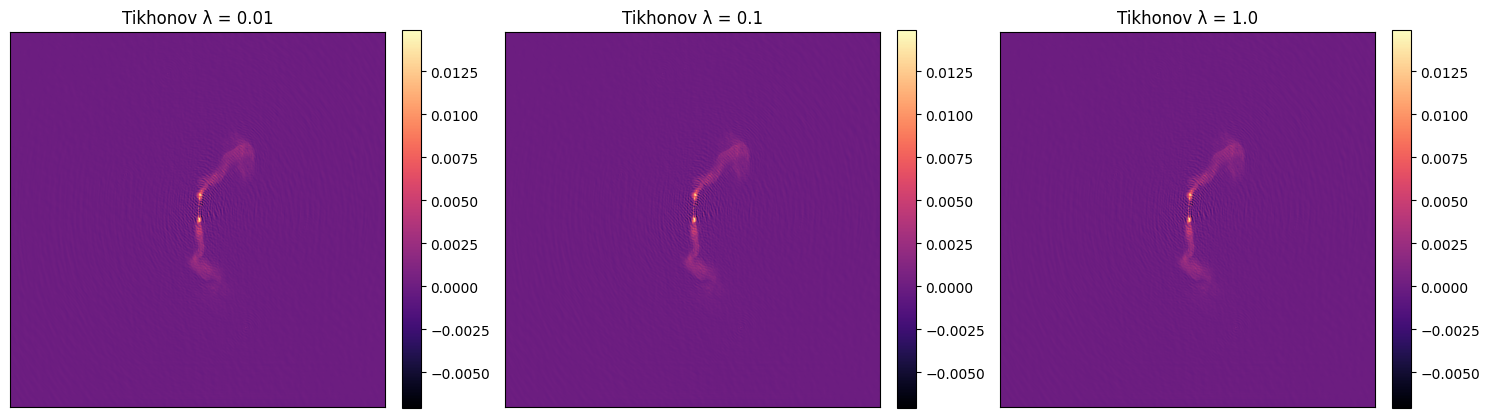

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, lam in enumerate(lambdas):
    im = axes[i].imshow(results[i], origin='lower', cmap='magma')
    axes[i].set_title(f"Tikhonov λ = {lam}")
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Larger $\lambda$ suppresses noise but reduces resolution; smaller $\lambda$ recovers fine structure at the cost of amplifying noise.


### **Uniform Weighting**

Natural weighting (using raw weights) maximises sensitivity but produces a broad PSF. Uniform weighting down-weights densely sampled UV cells to produce a narrower PSF at the cost of some sensitivity. Here we compute the UV-plane density and re-weight accordingly.


In [16]:
density_map = vis2dirty(
    uvw=uvw,
    freq=freq,
    vis=wgt.astype(vis.dtype),  # treat weights as visibilities
    npix_x=npix,
    npix_y=npix,
    pixsize_x=cell_rad,
    pixsize_y=cell_rad,
    epsilon=1e-6,
    do_wgridding=False,
    divide_by_n=False
).real

# Avoid division by zero
density_map = np.abs(density_map)
density_map[density_map == 0] = 1e-12

wgt_uniform = wgt / np.mean(wgt)

dirty_uniform = vis2dirty(
    uvw=uvw,
    freq=freq,
    vis=vis,
    wgt=wgt_uniform,
    mask=mask,
    npix_x=npix,
    npix_y=npix,
    pixsize_x=cell_rad,
    pixsize_y=cell_rad,
    epsilon=1e-6,
    do_wgridding=False,
    divide_by_n=False
)

psf_uniform = vis2dirty(
    uvw=uvw,
    freq=freq,
    vis=wgt_uniform.astype(vis.dtype),
    npix_x=npix_psf,
    npix_y=npix_psf,
    pixsize_x=cell_rad,
    pixsize_y=cell_rad,
    epsilon=1e-6,
    do_wgridding=False,
    divide_by_n=False
)

In [17]:
wsum_uniform = psf_uniform.max()
psf_uniform /= wsum_uniform
dirty_uniform /= wsum_uniform

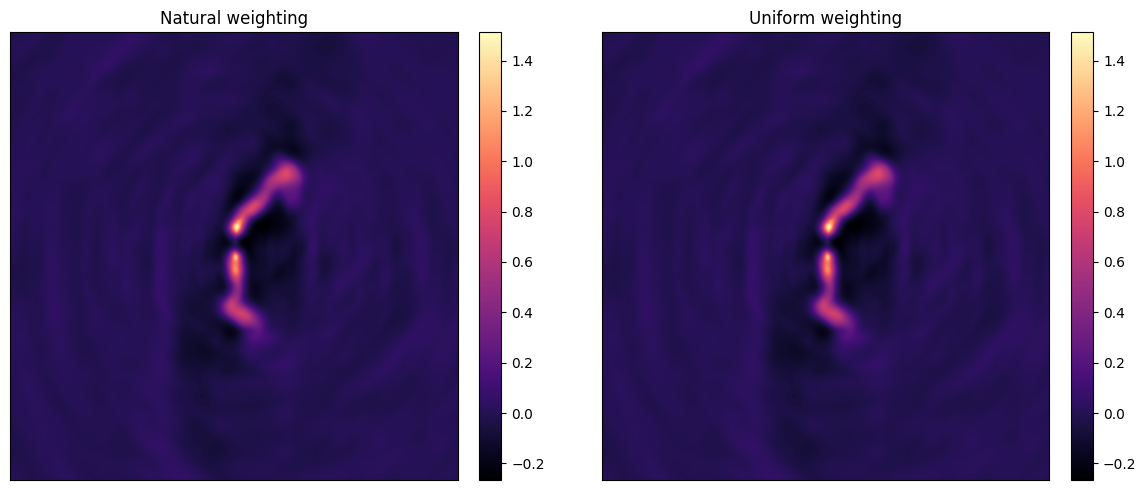

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(dirty_image, origin='lower', cmap='magma')
axes[0].set_title("Natural weighting")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(dirty_uniform, origin='lower', cmap='magma')
axes[1].set_title("Uniform weighting")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()


#### Advantages
- **Improves resolution**: Gives more weight to longer baselines, leading to sharper images.
- **Reduces sidelobes**: Produces a cleaner point spread function (PSF) in the image.
- **Better conditioning for some inversions**: Reduces the impact of very dense UV regions that can dominate the solution.

#### Disadvantages
- **Increases noise per pixel**: Since low-density regions are amplified, the image noise can increase.
- **Can reduce sensitivity to extended emission**: Small baselines get downweighted, so diffuse structures may be suppressed.
- **May require careful normalization**: To maintain physical flux units, one must account for the weighting factor.

###  **Diagonal Preconditioning**

Preconditioning the CG solver with an approximate inverse of the Hessian diagonal speeds up convergence. We use the PSF centre value as a scalar approximation to the diagonal of $H$, yielding the preconditioner $M^{-1} = (H_{\rm peak} + \lambda)^{-1}$.


In [19]:
# Approximate diagonal of H using PSF center
psf_center_val = psf_full[npix_psf//2, npix_psf//2]

# Build diagonal preconditioner
M_inv = 1.0 / (psf_center_val + lam_tik)

In [20]:
def conjugate_gradient_precond(A, b, M_inv, max_iter=200, tol=1e-6):
    x = torch.zeros_like(b)

    r = b - A(x)
    z = M_inv * r
    p = z.clone()
    rz_old = torch.sum(r * z)

    for i in range(max_iter):
        Ap = A(p)
        alpha = rz_old / torch.sum(p * Ap)

        x = x + alpha * p
        r = r - alpha * Ap

        if torch.norm(r) < tol:
            break

        z = M_inv * r
        rz_new = torch.sum(r * z)

        beta = rz_new / rz_old
        p = z + beta * p

        rz_old = rz_new

    return x

In [21]:
x_tik_precond = conjugate_gradient_precond(
    hessian_plus_reg,
    dirty_torch,
    M_inv=torch.tensor(M_inv, dtype=torch.float32),
    max_iter=200,
    tol=1e-6
)

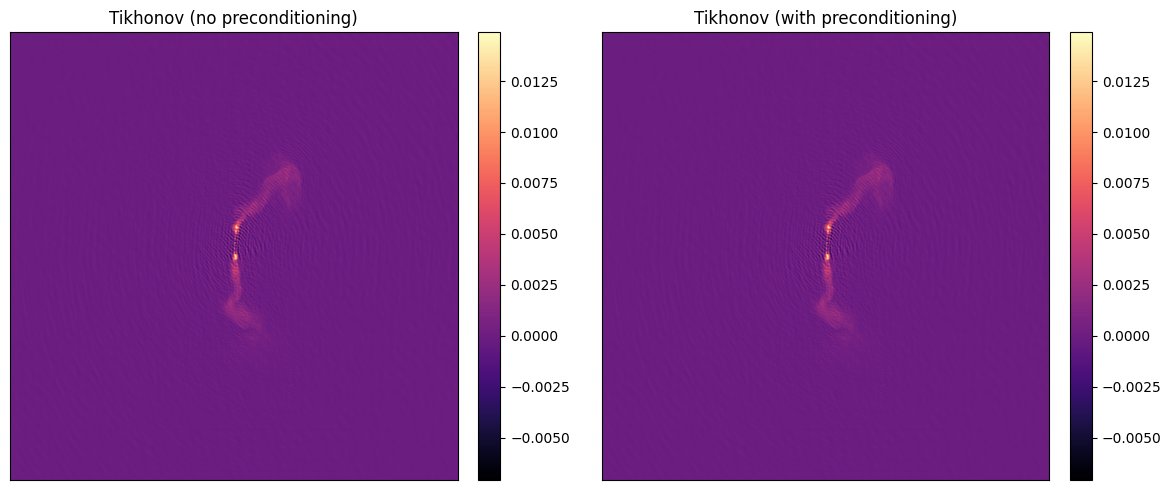

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(x_tik.numpy(), origin='lower', cmap='magma')
axes[0].set_title("Tikhonov (no preconditioning)")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(x_tik_precond.numpy(), origin='lower', cmap='magma')
axes[1].set_title("Tikhonov (with preconditioning)")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

#### Advantages
- **Speeds up convergence**: Reduces the number of iterations needed in poorly conditioned systems.
- **Easy to implement**: Only requires the diagonal of the system matrix, no full matrix inversion.
- **Low computational cost**: Much cheaper than full preconditioning techniques.
- **Stabilizes iterative solvers**: Especially useful when different variables have very different scales.

#### Disadvantages
- **Approximate**: Only considers the diagonal, ignores off-diagonal correlations.
- **Limited improvement**: May not help much for strongly coupled systems.
- **Requires diagonal computation**: For some operators implemented as functions (like convolution with PSF), computing the diagonal may require approximations.

## **Method : Non-negative Least Squares (NNLS)**

Tikhonov regularisation does not enforce the physical constraint that sky brightness must be non-negative. NNLS addresses this by solving:

$$
\hat{x} = \arg\min_x \; f(x) \quad \text{subject to} \quad x \geq 0
$$

There is no explicit smoothness penalty. Instead, the non-negativity constraint itself acts as an implicit regulariser by preventing the model from fitting noise through positive/negative cancellations.

The problem is solved using **projected gradient descent**:

$$
x_{k+1} = \max\!\Big(0,\; x_k - \gamma \,\nabla f(x_k)\Big)
$$

where negative values are clipped to zero after each gradient step.

The step size must satisfy:

$$
\gamma < \frac{2}{L}
$$

with $L$ the Lipschitz constant of the gradient.


In [23]:
def nnls_solver(A, b, max_iter=2000, lr=0.5, tol=1e-6, verbose=True):
    """
    Solve min ||A(x) - b||^2 subject to x >= 0 using Projected Gradient Descent (NNLS).

    Args:
        A: function applying the linear operator to x
        b: target tensor (dirty image)
        max_iter: maximum iterations
        lr: step size (learning rate)
        tol: tolerance for stopping criterion
        verbose: whether to print convergence info

    Returns:
        x: NNLS solution (same shape as b)
    """
    # Normalize b to avoid very small values
    scale = b.max()
    b_norm = b / scale

    x = torch.zeros_like(b_norm)

    for i in range(max_iter):
        grad = A(x) - b_norm
        x = x - lr * grad
        x = torch.clamp(x, min=0)  # projection onto x >= 0

        grad_norm = torch.norm(grad).item()

        # Print convergence message
        if verbose and i % 100 == 0:
            print(f"Iteration {i:4d}, gradient norm = {grad_norm:.3e}")

        if grad_norm < tol:
            if verbose:
                print(f"Converged at iteration {i} with gradient norm {grad_norm:.3e}")
            break

    return x * scale  # rescale back to original units

Iteration    0, gradient norm = 7.272e+01


/usr/local/lib/python3.12/dist-packages/scipy/signal/_signaltools.py:568: RuntimeWarning: invalid value encountered in multiply
  ret = ifft(sp1 * sp2, fshape, axes=axes)


Iteration  100, gradient norm = nan
Iteration  200, gradient norm = nan


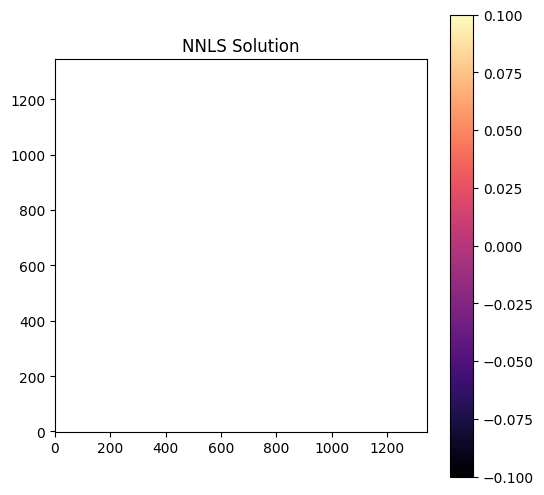

In [24]:
x_nnls = nnls_solver(hessian_plus_reg, dirty_torch, max_iter=300, lr=0.1)

plt.figure(figsize=(6,6))
plt.imshow(x_nnls.numpy(), origin='lower', cmap='magma')
plt.title("NNLS Solution")
plt.colorbar()
plt.show()



#### Advantages
- Physically motivated
- No tuning parameter required
- Effective at recovering **compact point sources**

#### Disadvantages in this context
- Convergence can be slow for large images
- Does **not enforce smoothness**, so extended emission appears noisy or speckled
- For diffuse structures like the ESO137 field, NNLS **does not give meaningful results**
- Step size and number of iterations must be carefully tuned

> **Note:** While NNLS can be applied, for extended emission and highly ill-conditioned systems it often fails to produce meaningful results. This is because NNLS only enforces **non-negativity** and does not encode smoothness, so diffuse structures remain noisy or largely zero. Methods like **Tikhonov regularization** or **preconditioned conjugate gradient** are more reliable for reconstructing extended emission.